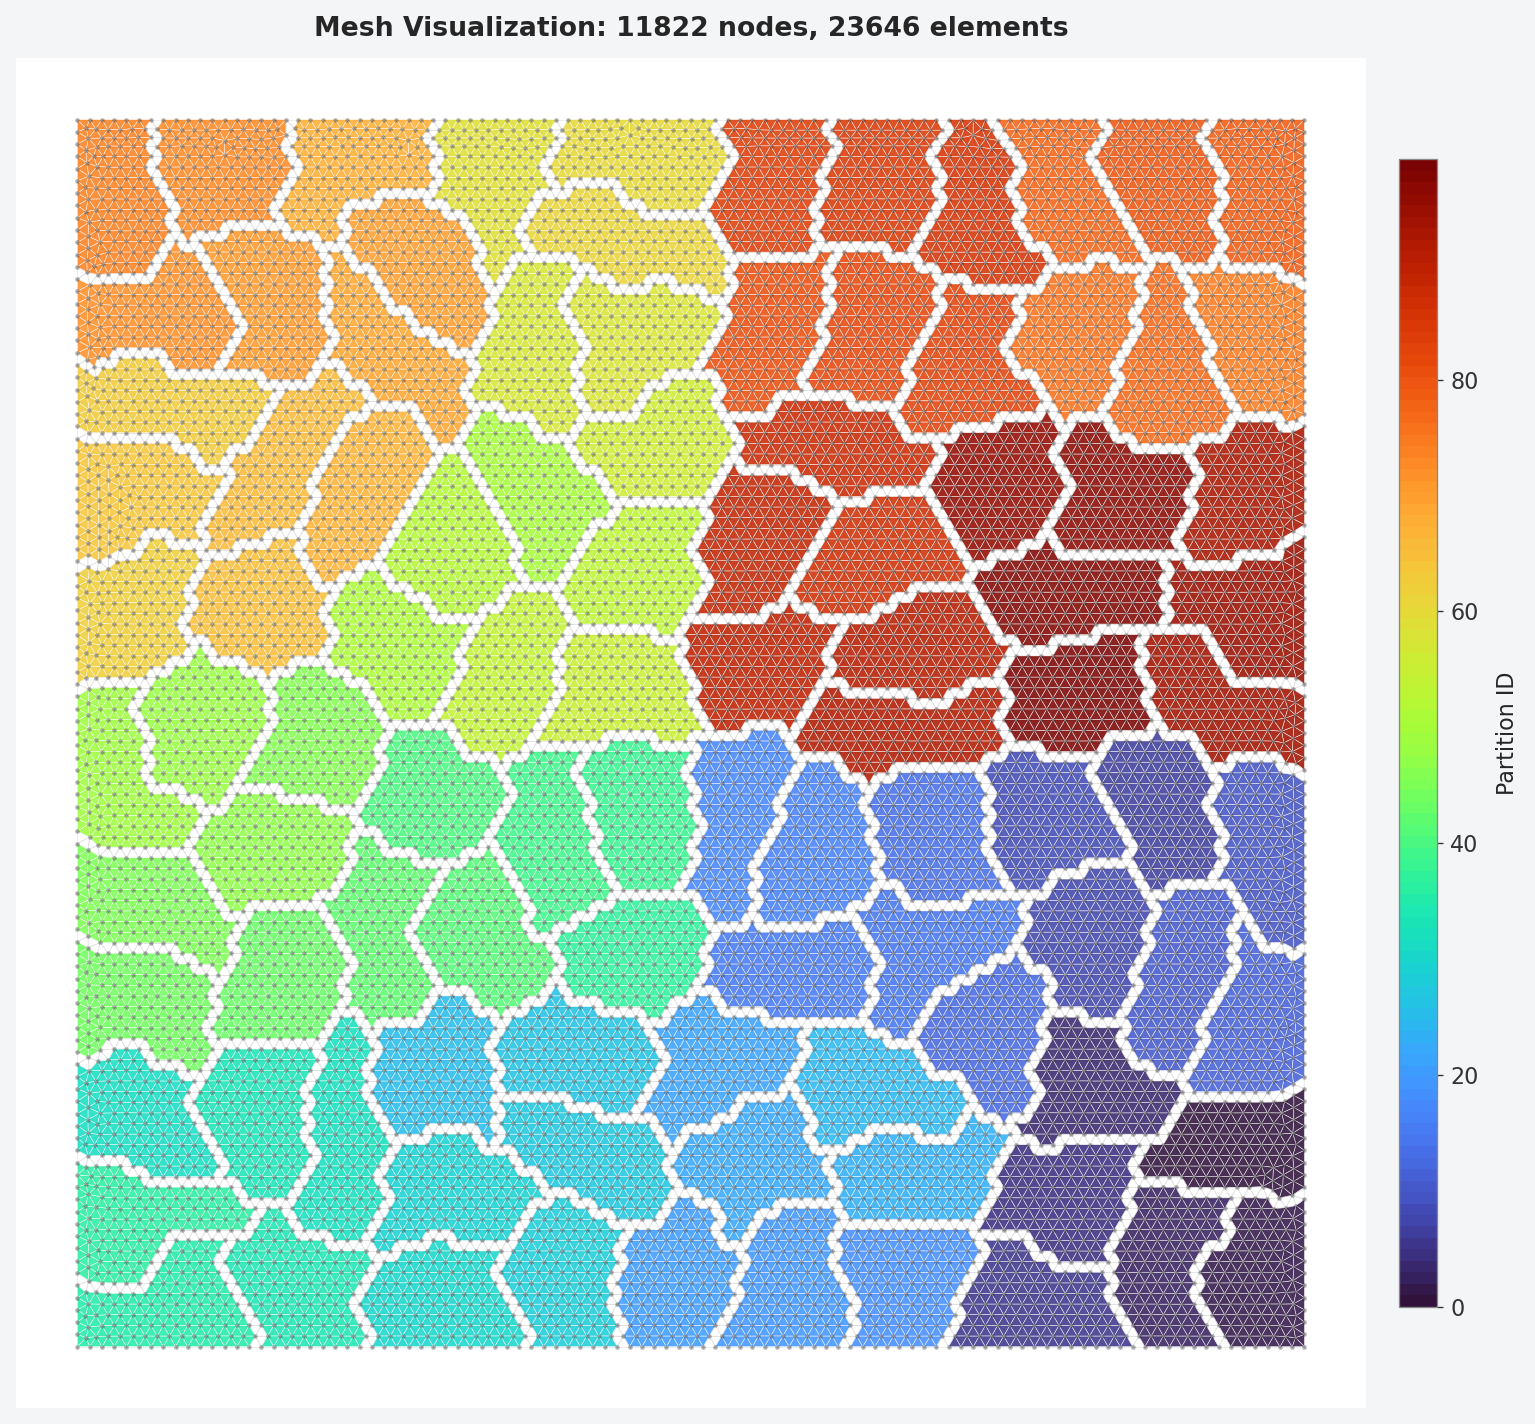

Number of nodes: 11822
Number of elements: 23646


In [1]:
import numpy as np
from matplotlib.collections import LineCollection, PolyCollection

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-white')

def read_msh_file(filename):
    """Read a .msh file and extract nodes and elements"""
    nodes = {}
    elements = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find $Nodes section
    node_start = None
    node_end = None
    for i, line in enumerate(lines):
        if '$Nodes' in line:
            node_start = i + 1
        elif '$EndNodes' in line:
            node_end = i
            break
    
    # Read nodes
    if node_start is not None and node_end is not None:
        num_nodes = int(lines[node_start].strip())
        for i in range(node_start + 1, node_end):
            parts = lines[i].strip().split()
            node_id = int(parts[0])
            x, y = float(parts[1]), float(parts[2])
            nodes[node_id] = (x, y)
    
    # Find $Elements section
    elem_start = None
    elem_end = None
    for i, line in enumerate(lines):
        if '$Elements' in line:
            elem_start = i + 1
        elif '$EndElements' in line:
            elem_end = i
            break
    
    # Read elements
    if elem_start is not None and elem_end is not None:
        num_elements = int(lines[elem_start].strip())
        for i in range(elem_start + 1, elem_end):
            parts = lines[i].strip().split()
            elem_id = int(parts[0])
            elem_type = int(parts[1])
            num_tags = int(parts[2])
            node_list = [int(parts[3 + num_tags + j]) for j in range(len(parts) - 3 - num_tags)]
            elements.append((elem_type, node_list))
    
    return nodes, elements

def read_partition(filename):
    """Read partition.txt and return a list of part ids (0-based)."""
    with open(filename, 'r') as f:
        data = f.read().strip().split()
    return [int(x) for x in data]

# Read the mesh file
nodes, elements = read_msh_file('../data/rect.msh')

# Read partition file
parts = read_partition('partition.txt')

# Visualize the mesh
fig, ax = plt.subplots(figsize=(11, 9), dpi=160)
fig.patch.set_facecolor('#f4f5f7')
ax.set_facecolor('#ffffff')

# Plot nodes with colors by partition
node_ids = sorted(nodes.keys())
node_coords = np.array([nodes[nid] for nid in node_ids])
if len(parts) >= len(node_ids):
    node_parts = np.array([parts[nid - 1] for nid in node_ids])
else:
    node_parts = np.zeros(len(node_ids), dtype=int)
    print("Warning: partition.txt has fewer entries than nodes.")

num_parts = int(node_parts.max()) + 1 if len(node_parts) else 1
cmap = plt.get_cmap('turbo', num_parts)

# Build element (triangle) faces colored by partition if all 3 nodes share the same part
part_by_id = {nid: node_parts[i] for i, nid in enumerate(node_ids)}
faces = []
face_colors = []
edge_segs = []
for elem_type, node_list in elements:
    if elem_type == 2 and len(node_list) == 3:
        p0 = part_by_id.get(node_list[0], None)
        p1 = part_by_id.get(node_list[1], None)
        p2 = part_by_id.get(node_list[2], None)
        pts = [nodes[node_list[0]], nodes[node_list[1]], nodes[node_list[2]]]
        edge_segs.extend([[pts[0], pts[1]], [pts[1], pts[2]], [pts[2], pts[0]]])
        if p0 is not None and p0 == p1 == p2:
            faces.append(pts)
            face_colors.append(cmap(p0))

if faces:
    poly = PolyCollection(
        faces,
        facecolors=face_colors,
        edgecolors='white',
        linewidths=0.25,
        alpha=0.88,
        zorder=2
    )
    ax.add_collection(poly)

# Subtle mesh edges for structure
if edge_segs:
    lc = LineCollection(
        edge_segs,
        colors='#d9d9d9',
        linewidths=0.35,
        alpha=0.6,
        zorder=1
    )
    ax.add_collection(lc)

# Optional: draw nodes lightly on top
ax.scatter(
    node_coords[:, 0],
    node_coords[:, 1],
    c='#1f1f1f',
    s=1.5,
    alpha=0.25,
    zorder=3,
    rasterized=True
  )

# Nice-looking colorbar
norm = plt.Normalize(vmin=0, vmax=max(num_parts - 1, 1))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02,
    fraction=0.03,
    aspect=30,
    shrink=0.85
  )
cbar.set_label('Partition ID', labelpad=8)
cbar.outline.set_linewidth(0.6)
cbar.outline.set_edgecolor('#888888')
cbar.ax.tick_params(length=2.5, width=0.6, colors='#333333')

ax.set_aspect('equal')
ax.set_title(
    f'Mesh Visualization: {len(nodes)} nodes, {len(elements)} elements',
    pad=10,
    fontweight='semibold'
  )
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)

plt.tight_layout()
plt.show()

print(f"Number of nodes: {len(nodes)}")
print(f"Number of elements: {len(elements)}")